In [1]:
import os
import json
from pathlib import Path
from PIL import Image
from collections import defaultdict
import torch
import torch.nn.functional as F

In [2]:

BASE_DIR = Path("/home/jupyter-st126222/Project/rdd2022")
FILTERED_DIR = BASE_DIR / "data" / "RDD_FILTERED"
COCO_DIR = BASE_DIR / "data" / "RDD_COCO"
COCO_DIR.mkdir(parents=True, exist_ok=True)

CLASSES = ["D00", "D10", "D20", "D40"]
NUM_CLASSES = 4

def yolo_to_coco(split):
    img_dir = FILTERED_DIR / split / "images"
    label_dir = FILTERED_DIR / split / "labels"
    
    images = []
    annotations = []
    ann_id = 1
    
    for img_id, img_path in enumerate(sorted(img_dir.iterdir()), start=1):
        img = Image.open(img_path)
        w, h = img.size
        images.append({
            "id": img_id,
            "file_name": img_path.name,
            "width": w,
            "height": h
        })
        
        label_path = label_dir / (img_path.stem + ".txt")
        if label_path.exists():
            with open(label_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if not parts: continue
                    cls = int(parts[0])
                    if cls >= NUM_CLASSES: continue
                    cx, cy, bw, bh = map(float, parts[1:])
                    
                    x_min = (cx - bw/2) * w
                    y_min = (cy - bh/2) * h
                    box_w = bw * w
                    box_h = bh * h
                    
                    annotations.append({
                        "id": ann_id,
                        "image_id": img_id,
                        "category_id": cls,  # ← FIXED: 0-indexed to match DETR convention
                        "bbox": [x_min, y_min, box_w, box_h],
                        "area": box_w * box_h,
                        "iscrowd": 0
                    })
                    ann_id += 1
    
    categories = [{"id": i, "name": name} for i, name in enumerate(CLASSES)]  # ← FIXED: starts at 0
    
    coco_dict = {
        "images": images,
        "annotations": annotations,
        "categories": categories
    }
    
    out_path = COCO_DIR / f"{split}_annotations.json"
    with open(out_path, "w") as f:
        json.dump(coco_dict, f)
    
    print(f"✓ {split}: {len(images)} images, {len(annotations)} annotations → {out_path}")

for split in ["train", "val", "test"]:
    yolo_to_coco(split)

✓ train: 25194 images, 39075 annotations → /home/jupyter-st126222/Project/rdd2022/data/RDD_COCO/train_annotations.json
✓ val: 5409 images, 8219 annotations → /home/jupyter-st126222/Project/rdd2022/data/RDD_COCO/val_annotations.json
✓ test: 5381 images, 8120 annotations → /home/jupyter-st126222/Project/rdd2022/data/RDD_COCO/test_annotations.json


In [3]:
from transformers import DetrForObjectDetection, DetrImageProcessor

MODEL_NAME = "facebook/detr-resnet-50"

processor = DetrImageProcessor.from_pretrained(MODEL_NAME)

model = DetrForObjectDetection.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True  # replace COCO's 91-class head with our 4-class head
)

print(f"✓ Model loaded: {MODEL_NAME}")
print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"  Device available: {"cuda:1" if torch.cuda.is_available() else "cpu"}")

[transformers] You passed `num_labels=4` which is incompatible to the `id2label` map of length `91`.


Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

[transformers] DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |                                                                                        
---------------------------------------------------------------+------------+----------------------------------------------------------------------------------------
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |             

✓ Model loaded: facebook/detr-resnet-50
  Parameters: 41,502,409
  Device available: cuda:1


In [4]:
from torch.utils.data import Dataset
from pycocotools.coco import COCO

class RDDCocoDataset(Dataset):
    def __init__(self, img_dir, ann_file, processor):
        self.img_dir = Path(img_dir)
        self.coco = COCO(str(ann_file))
        self.img_ids = list(sorted(self.coco.imgs.keys()))
        self.processor = processor

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        img_info = self.coco.imgs[img_id]
        img_path = self.img_dir / img_info["file_name"]
        image = Image.open(img_path).convert("RGB")

        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)

        target = {"image_id": img_id, "annotations": anns}
        encoding = self.processor(images=image, annotations=target, return_tensors="pt")

        pixel_values = encoding["pixel_values"].squeeze()
        target = encoding["labels"][0]
        return pixel_values, target


def collate_fn(batch):
    pixel_values = [item[0] for item in batch]
    labels = [item[1] for item in batch]
    
    # Find max height and width in this batch
    max_h = max(img.shape[1] for img in pixel_values)
    max_w = max(img.shape[2] for img in pixel_values)
    
    padded_imgs = []
    pixel_masks = []
    for img in pixel_values:
        c, h, w = img.shape
        pad_h = max_h - h
        pad_w = max_w - w
        # Pad on the bottom/right
        padded = F.pad(img, (0, pad_w, 0, pad_h), value=0)
        padded_imgs.append(padded)
        
        mask = torch.zeros((max_h, max_w), dtype=torch.long)
        mask[:h, :w] = 1
        pixel_masks.append(mask)
    
    pixel_values_batch = torch.stack(padded_imgs)
    pixel_mask_batch = torch.stack(pixel_masks)
    
    return {
        "pixel_values": pixel_values_batch,
        "pixel_mask": pixel_mask_batch,
        "labels": labels
    }

train_dataset = RDDCocoDataset(
    img_dir=FILTERED_DIR / "train" / "images",
    ann_file=COCO_DIR / "train_annotations.json",
    processor=processor
)
val_dataset = RDDCocoDataset(
    img_dir=FILTERED_DIR / "val" / "images",
    ann_file=COCO_DIR / "val_annotations.json",
    processor=processor
)

print(f"✓ Train dataset: {len(train_dataset)} images")
print(f"✓ Val dataset: {len(val_dataset)} images")

loading annotations into memory...
Done (t=0.20s)
creating index...
index created!
loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
✓ Train dataset: 25194 images
✓ Val dataset: 5409 images


In [5]:
pixel_values, target = train_dataset[0]
print(f"Pixel values shape: {pixel_values.shape}")
print(f"Target keys: {target.keys()}")
print(f"Number of boxes: {len(target['boxes'])}")
print(f"Class labels: {target['class_labels']}")

Pixel values shape: torch.Size([3, 800, 800])
Target keys: KeysView({'size': tensor([800, 800]), 'image_id': tensor([1]), 'class_labels': tensor([3, 2, 2, 0]), 'boxes': tensor([[0.6377, 0.5625, 0.7246, 0.8750],
        [0.6650, 0.1768, 0.6699, 0.3496],
        [0.9092, 0.4639, 0.1816, 0.2246],
        [0.2656, 0.0449, 0.0469, 0.0859]]), 'area': tensor([405781.0312, 149894.8906,  26110.8496,   2578.1399]), 'iscrowd': tensor([0, 0, 0, 0]), 'orig_size': tensor([512, 512])})
Number of boxes: 4
Class labels: tensor([3, 2, 2, 0])


In [6]:
from torch.utils.data import DataLoader

BATCH_SIZE = 2  # DETR is memory-heavy, start conservative

train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=4
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=4
)

# Test one batch
batch = next(iter(train_dataloader))
print(f"Pixel values shape : {batch['pixel_values'].shape}")
print(f"Pixel mask shape   : {batch['pixel_mask'].shape}")
print(f"Number of labels   : {len(batch['labels'])}")

Pixel values shape : torch.Size([2, 3, 800, 800])
Pixel mask shape   : torch.Size([2, 800, 800])
Number of labels   : 2


In [8]:
from torch.optim import AdamW

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
model.to(device)

# Lower LR for fine-tuning pretrained backbone + lower LR for new head
optimizer = AdamW(model.parameters(), lr=1e-5, weight_decay=1e-4)

NUM_EPOCHS = 5
MAX_GRAD_NORM = 0.1  # gradient clipping to prevent explosion

print(f"✓ Model on device: {device}")
print(f"✓ Optimizer: AdamW, lr=1e-5 (reduced for stability)")
print(f"✓ Gradient clipping: max_norm={MAX_GRAD_NORM}")

✓ Model on device: cuda:1
✓ Optimizer: AdamW, lr=1e-5 (reduced for stability)
✓ Gradient clipping: max_norm=0.1


In [7]:
import time

model.train()

# Speed test: time 10 steps
start = time.time()
for i, batch in enumerate(train_dataloader):
    pixel_values = batch["pixel_values"].to(device)
    pixel_mask = batch["pixel_mask"].to(device)
    labels = [{k: v.to(device) for k, v in t.items()} for t in batch["labels"]]
    
    outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask, labels=labels)
    loss = outputs.loss
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if i == 0:
        print(f"Step {i}: loss={loss.item():.4f}")
    if i >= 9:
        break

elapsed = time.time() - start
time_per_step = elapsed / 10
steps_per_epoch = len(train_dataloader)
time_per_epoch = time_per_step * steps_per_epoch

print(f"\n✓ 10 steps took {elapsed:.1f}s ({time_per_step:.2f}s/step)")
print(f"  Estimated time per epoch: {time_per_epoch/60:.1f} minutes")
print(f"  Estimated time for {NUM_EPOCHS} epochs: {time_per_epoch*NUM_EPOCHS/3600:.1f} hours")

NameError: name 'device' is not defined

In [19]:
import time

SAVED_DIR = BASE_DIR / "saved"
SAVED_DIR.mkdir(parents=True, exist_ok=True)
checkpoint_path = SAVED_DIR / "detr_rdd2022"
checkpoint_path.mkdir(parents=True, exist_ok=True)

model.train()
train_losses = []
start_time = time.time()

for epoch in range(NUM_EPOCHS):
    epoch_loss = 0
    epoch_start = time.time()
    
    for i, batch in enumerate(train_dataloader):
        pixel_values = batch["pixel_values"].to(device)
        pixel_mask = batch["pixel_mask"].to(device)
        labels = [{k: v.to(device) for k, v in t.items()} for t in batch["labels"]]
        
        outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask, labels=labels)
        loss = outputs.loss
        
        if not torch.isfinite(loss):
            print(f"  ⚠ Skipping step {i} — non-finite loss detected")
            optimizer.zero_grad()
            continue
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
        optimizer.step()
        
        epoch_loss += loss.item()
        
        if i % 500 == 0:
            print(f"  Epoch {epoch+1}/{NUM_EPOCHS} | Step {i}/{len(train_dataloader)} | Loss: {loss.item():.4f}")
    
    avg_loss = epoch_loss / len(train_dataloader)
    train_losses.append(avg_loss)
    epoch_time = time.time() - epoch_start
    
    print(f"✓ Epoch {epoch+1} done | Avg loss: {avg_loss:.4f} | Time: {epoch_time/60:.1f} min")
    
    model.save_pretrained(checkpoint_path / f"epoch_{epoch+1}")
    print(f"  Checkpoint saved to {checkpoint_path / f'epoch_{epoch+1}'}")

total_time = time.time() - start_time
print(f"\n✓ Training complete in {total_time/3600:.2f} hours")
print(f"  Final loss: {train_losses[-1]:.4f}")

  Epoch 1/5 | Step 0/12597 | Loss: 2.3750
  Epoch 1/5 | Step 500/12597 | Loss: 3.5028
  Epoch 1/5 | Step 1000/12597 | Loss: 1.8234
  Epoch 1/5 | Step 1500/12597 | Loss: 1.1482
  Epoch 1/5 | Step 2000/12597 | Loss: 2.5352
  Epoch 1/5 | Step 2500/12597 | Loss: 0.6728
  Epoch 1/5 | Step 3000/12597 | Loss: 2.1002
  Epoch 1/5 | Step 3500/12597 | Loss: 0.0002
  Epoch 1/5 | Step 4000/12597 | Loss: 1.1375
  Epoch 1/5 | Step 4500/12597 | Loss: 1.9332
  Epoch 1/5 | Step 5000/12597 | Loss: 2.9941
  Epoch 1/5 | Step 5500/12597 | Loss: 2.5788
  Epoch 1/5 | Step 6000/12597 | Loss: 0.9673
  Epoch 1/5 | Step 6500/12597 | Loss: 1.3314
  Epoch 1/5 | Step 7000/12597 | Loss: 2.5409
  Epoch 1/5 | Step 7500/12597 | Loss: 0.9711
  Epoch 1/5 | Step 8000/12597 | Loss: 1.5380
  Epoch 1/5 | Step 8500/12597 | Loss: 2.8779
  Epoch 1/5 | Step 9000/12597 | Loss: 2.2124
  Epoch 1/5 | Step 9500/12597 | Loss: 1.8420
  Epoch 1/5 | Step 10000/12597 | Loss: 1.7018
  Epoch 1/5 | Step 10500/12597 | Loss: 1.6689
  Epoch 1/5 

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Checkpoint saved to /home/jupyter-st126222/Project/rdd2022/saved/detr_rdd2022/epoch_1
  Epoch 2/5 | Step 0/12597 | Loss: 3.0624
  Epoch 2/5 | Step 500/12597 | Loss: 1.1775
  Epoch 2/5 | Step 1000/12597 | Loss: 0.0038
  Epoch 2/5 | Step 1500/12597 | Loss: 1.5863
  Epoch 2/5 | Step 2000/12597 | Loss: 5.1423
  Epoch 2/5 | Step 2500/12597 | Loss: 2.0960
  Epoch 2/5 | Step 3000/12597 | Loss: 1.6129
  Epoch 2/5 | Step 3500/12597 | Loss: 1.6160
  Epoch 2/5 | Step 4000/12597 | Loss: 0.0000
  Epoch 2/5 | Step 4500/12597 | Loss: 0.6133
  Epoch 2/5 | Step 5000/12597 | Loss: 1.0074
  Epoch 2/5 | Step 5500/12597 | Loss: 1.0533
  Epoch 2/5 | Step 6000/12597 | Loss: 1.7521
  Epoch 2/5 | Step 6500/12597 | Loss: 1.7609
  Epoch 2/5 | Step 7000/12597 | Loss: 2.4154
  Epoch 2/5 | Step 7500/12597 | Loss: 1.2703
  Epoch 2/5 | Step 8000/12597 | Loss: 1.4655
  Epoch 2/5 | Step 8500/12597 | Loss: 0.0009
  Epoch 2/5 | Step 9000/12597 | Loss: 1.4642
  Epoch 2/5 | Step 9500/12597 | Loss: 1.4395
  Epoch 2/5 | St

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Checkpoint saved to /home/jupyter-st126222/Project/rdd2022/saved/detr_rdd2022/epoch_2
  Epoch 3/5 | Step 0/12597 | Loss: 0.7422
  Epoch 3/5 | Step 500/12597 | Loss: 1.8982
  Epoch 3/5 | Step 1000/12597 | Loss: 1.7592
  Epoch 3/5 | Step 1500/12597 | Loss: 2.3466
  Epoch 3/5 | Step 2000/12597 | Loss: 1.4670
  Epoch 3/5 | Step 2500/12597 | Loss: 3.6299
  Epoch 3/5 | Step 3000/12597 | Loss: 2.4448
  Epoch 3/5 | Step 3500/12597 | Loss: 1.6383
  Epoch 3/5 | Step 4000/12597 | Loss: 1.0766
  Epoch 3/5 | Step 4500/12597 | Loss: 1.0770
  Epoch 3/5 | Step 5000/12597 | Loss: 1.9567
  Epoch 3/5 | Step 5500/12597 | Loss: 1.7005
  Epoch 3/5 | Step 6000/12597 | Loss: 1.3819
  Epoch 3/5 | Step 6500/12597 | Loss: 3.5070
  Epoch 3/5 | Step 7000/12597 | Loss: 2.4851
  Epoch 3/5 | Step 7500/12597 | Loss: 1.3448
  Epoch 3/5 | Step 8000/12597 | Loss: 0.9038
  Epoch 3/5 | Step 8500/12597 | Loss: 1.3167
  Epoch 3/5 | Step 9000/12597 | Loss: 1.2570
  Epoch 3/5 | Step 9500/12597 | Loss: 1.2633
  Epoch 3/5 | St

...

  Checkpoint saved to /home/jupyter-st126222/Project/rdd2022/saved/detr_rdd2022/epoch_3
  Epoch 4/5 | Step 0/12597 | Loss: 1.4530
  Epoch 4/5 | Step 500/12597 | Loss: 0.0000
  Epoch 4/5 | Step 1000/12597 | Loss: 2.0852
  Epoch 4/5 | Step 1500/12597 | Loss: 0.8010
  Epoch 4/5 | Step 2000/12597 | Loss: 1.3722
  Epoch 4/5 | Step 2500/12597 | Loss: 1.5321
  Epoch 4/5 | Step 3000/12597 | Loss: 1.0762
  Epoch 4/5 | Step 3500/12597 | Loss: 2.2624
  Epoch 4/5 | Step 4000/12597 | Loss: 0.0001
  Epoch 4/5 | Step 4500/12597 | Loss: 1.6327
  Epoch 4/5 | Step 5000/12597 | Loss: 2.7605
  Epoch 4/5 | Step 5500/12597 | Loss: 0.0000
  Epoch 4/5 | Step 6000/12597 | Loss: 0.5409
  Epoch 4/5 | Step 6500/12597 | Loss: 0.5934
  Epoch 4/5 | Step 7000/12597 | Loss: 1.4628
  Epoch 4/5 | Step 7500/12597 | Loss: 0.3866
  Epoch 4/5 | Step 8000/12597 | Loss: 1.9747
  Epoch 4/5 | Step 8500/12597 | Loss: 1.7386
  Epoch 4/5 | Step 9000/12597 | Loss: 1.9339
  Epoch 4/5 | Step 9500/12597 | Loss: 1.0046
  Epoch 4/5 | St

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Checkpoint saved to /home/jupyter-st126222/Project/rdd2022/saved/detr_rdd2022/epoch_4
  Epoch 5/5 | Step 0/12597 | Loss: 2.1006
  Epoch 5/5 | Step 500/12597 | Loss: 1.4840
  Epoch 5/5 | Step 1000/12597 | Loss: 1.3064
  Epoch 5/5 | Step 1500/12597 | Loss: 1.3856
  Epoch 5/5 | Step 2000/12597 | Loss: 0.5598
  Epoch 5/5 | Step 2500/12597 | Loss: 0.8303
  Epoch 5/5 | Step 3000/12597 | Loss: 2.5894
  Epoch 5/5 | Step 3500/12597 | Loss: 2.1192
  Epoch 5/5 | Step 4000/12597 | Loss: 1.0659
  Epoch 5/5 | Step 4500/12597 | Loss: 0.7892
  Epoch 5/5 | Step 5000/12597 | Loss: 0.4309
  Epoch 5/5 | Step 5500/12597 | Loss: 0.9016
  Epoch 5/5 | Step 6000/12597 | Loss: 2.3798
  Epoch 5/5 | Step 6500/12597 | Loss: 0.7242
  Epoch 5/5 | Step 7000/12597 | Loss: 1.1888
  Epoch 5/5 | Step 7500/12597 | Loss: 1.4752
  Epoch 5/5 | Step 8000/12597 | Loss: 1.2226
  Epoch 5/5 | Step 8500/12597 | Loss: 2.6621
  Epoch 5/5 | Step 9000/12597 | Loss: 0.3040
  Epoch 5/5 | Step 9500/12597 | Loss: 1.0928
  Epoch 5/5 | St

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Checkpoint saved to /home/jupyter-st126222/Project/rdd2022/saved/detr_rdd2022/epoch_5

✓ Training complete in 7.48 hours
  Final loss: 1.1835


In [10]:
from transformers import DetrForObjectDetection, DetrImageProcessor
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from pathlib import Path
import torch

# Redefine paths directly
BASE_DIR = Path("/home/jupyter-st126222/Project/rdd2022")
SAVED_DIR = BASE_DIR / "saved"
FILTERED_DIR = BASE_DIR / "data" / "RDD_FILTERED"
COCO_DIR = BASE_DIR / "data" / "RDD_COCO"
checkpoint_path = SAVED_DIR / "detr_rdd2022"
CLASSES = ["D00", "D10", "D20", "D40"]
NUM_CLASSES = 4

device = torch.device("cuda:1")

# Load processor and best model from disk
processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")
model_eval = DetrForObjectDetection.from_pretrained(checkpoint_path / "epoch_5")
model_eval.to(device)
model_eval.eval()

print(f"✓ Model loaded from {checkpoint_path / 'epoch_5'}")
print(f"✓ Device: {device}")

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

✓ Model loaded from /home/jupyter-st126222/Project/rdd2022/saved/detr_rdd2022/epoch_5
✓ Device: cuda:1


In [11]:
from torch.utils.data import Dataset, DataLoader
from pycocotools.coco import COCO
from PIL import Image
import json

class RDDCocoDataset(Dataset):
    def __init__(self, img_dir, ann_file, processor):
        self.img_dir = Path(img_dir)
        self.coco = COCO(str(ann_file))
        self.img_ids = list(sorted(self.coco.imgs.keys()))
        self.processor = processor

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        img_info = self.coco.imgs[img_id]
        img_path = self.img_dir / img_info["file_name"]
        image = Image.open(img_path).convert("RGB")
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)
        target = {"image_id": img_id, "annotations": anns}
        encoding = self.processor(images=image, annotations=target, return_tensors="pt")
        pixel_values = encoding["pixel_values"].squeeze()
        target = encoding["labels"][0]
        return pixel_values, target

import torch.nn.functional as F

def collate_fn(batch):
    pixel_values = [item[0] for item in batch]
    labels = [item[1] for item in batch]
    max_h = max(img.shape[1] for img in pixel_values)
    max_w = max(img.shape[2] for img in pixel_values)
    padded_imgs = []
    pixel_masks = []
    for img in pixel_values:
        c, h, w = img.shape
        pad_h = max_h - h
        pad_w = max_w - w
        padded = F.pad(img, (0, pad_w, 0, pad_h), value=0)
        padded_imgs.append(padded)
        mask = torch.zeros((max_h, max_w), dtype=torch.long)
        mask[:h, :w] = 1
        pixel_masks.append(mask)
    return {
        "pixel_values": torch.stack(padded_imgs),
        "pixel_mask": torch.stack(pixel_masks),
        "labels": labels
    }

val_dataset = RDDCocoDataset(
    img_dir=FILTERED_DIR / "val" / "images",
    ann_file=COCO_DIR / "val_annotations.json",
    processor=processor
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0
)

print(f"✓ Val dataset: {len(val_dataset)} images")
print(f"✓ Val dataloader: {len(val_dataloader)} batches")

loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
✓ Val dataset: 5409 images
✓ Val dataloader: 1353 batches


In [13]:
# from torchmetrics.detection.mean_ap import MeanAveragePrecision
# import torch

# metric = MeanAveragePrecision(iou_type="bbox", iou_thresholds=[0.5])

# def yolo_to_xyxy_abs(boxes, orig_size):
#     # boxes: normalized [cx, cy, w, h] → absolute [x1, y1, x2, y2]
#     h, w = orig_size[0].item(), orig_size[1].item()
#     cx = boxes[:, 0] * w
#     cy = boxes[:, 1] * h
#     bw = boxes[:, 2] * w
#     bh = boxes[:, 3] * h
#     x1 = cx - bw / 2
#     y1 = cy - bh / 2
#     x2 = cx + bw / 2
#     y2 = cy + bh / 2
#     return torch.stack([x1, y1, x2, y2], dim=1)

# model_eval.eval()
# with torch.no_grad():
#     for i, batch in enumerate(val_dataloader):
#         pixel_values = batch["pixel_values"].to(device)
#         pixel_mask = batch["pixel_mask"].to(device)
#         labels = batch["labels"]

#         outputs = model_eval(pixel_values=pixel_values, pixel_mask=pixel_mask)

#         target_sizes = torch.stack([t["orig_size"] for t in labels])
#         results = processor.post_process_object_detection(
#             outputs, threshold=0.5, target_sizes=target_sizes
#         )

#         preds = [{
#             "boxes": r["boxes"].cpu(),
#             "scores": r["scores"].cpu(),
#             "labels": r["labels"].cpu()
#         } for r in results]

#         targets = [{
#             "boxes": yolo_to_xyxy_abs(t["boxes"], t["orig_size"]).cpu(),
#             "labels": t["class_labels"].cpu()
#         } for t in labels]

#         metric.update(preds, targets)

#         if i % 200 == 0:
#             print(f"  Evaluated {i}/{len(val_dataloader)} batches")

# results_map = metric.compute()
# print(f"\n✓ DETR Evaluation Results:")
# print(f"  mAP@50     : {results_map['map_50']:.4f}")
# print(f"  mAP@50-95  : {results_map['map']:.4f}")

In [15]:
# print("\nPer-class AP@50:")
# print(results_map)

In [16]:
# metric_perclass = MeanAveragePrecision(
#     iou_type="bbox",
#     iou_thresholds=[0.5],
#     class_metrics=True  # enable per-class metrics
# )

# model_eval.eval()
# with torch.no_grad():
#     for i, batch in enumerate(val_dataloader):
#         pixel_values = batch["pixel_values"].to(device)
#         pixel_mask = batch["pixel_mask"].to(device)
#         labels = batch["labels"]

#         outputs = model_eval(pixel_values=pixel_values, pixel_mask=pixel_mask)

#         target_sizes = torch.stack([t["orig_size"] for t in labels])
#         results = processor.post_process_object_detection(
#             outputs, threshold=0.5, target_sizes=target_sizes
#         )

#         preds = [{
#             "boxes": r["boxes"].cpu(),
#             "scores": r["scores"].cpu(),
#             "labels": r["labels"].cpu()
#         } for r in results]

#         targets = [{
#             "boxes": yolo_to_xyxy_abs(t["boxes"], t["orig_size"]).cpu(),
#             "labels": t["class_labels"].cpu()
#         } for t in labels]

#         metric_perclass.update(preds, targets)

#         if i % 200 == 0:
#             print(f"  Evaluated {i}/{len(val_dataloader)} batches")

# results_perclass = metric_perclass.compute()
# print(f"\n✓ DETR Results:")
# print(f"  mAP@50     : {results_perclass['map_50']:.4f}")
# print(f"  mAP@50-95  : {results_perclass['map']:.4f}")
# print(f"\nPer-class AP@50:")
# for cls_id, name in enumerate(CLASSES):
#     ap = results_perclass["map_per_class"][cls_id].item()
#     print(f"  {name}: {ap:.4f}")

In [17]:
import time
from torch.optim import AdamW

# Fresh model load for full training
from transformers import DetrForObjectDetection, DetrImageProcessor

processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")
model = DetrForObjectDetection.from_pretrained(
    "facebook/detr-resnet-50",
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True
)

device = torch.device("cuda:1")
model.to(device)

optimizer = AdamW(model.parameters(), lr=1e-5, weight_decay=1e-4)
MAX_GRAD_NORM = 0.1
NUM_EPOCHS = 20

SAVED_DIR = BASE_DIR / "saved"
checkpoint_path = SAVED_DIR / "detr_rdd2022_full"
checkpoint_path.mkdir(parents=True, exist_ok=True)

# Full dataset dataloader
train_dataloader_full = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=4
)

print(f"✓ Training on GPU: {device}")
print(f"✓ Full dataset: {len(train_dataset)} images")
print(f"✓ Steps per epoch: {len(train_dataloader_full)}")
print(f"✓ Total epochs: {NUM_EPOCHS}")
print(f"✓ Checkpoints: {checkpoint_path}")

[transformers] You passed `num_labels=4` which is incompatible to the `id2label` map of length `91`.


Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

[transformers] DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |                                                                                        
---------------------------------------------------------------+------------+----------------------------------------------------------------------------------------
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |             

✓ Training on GPU: cuda:1
✓ Full dataset: 25194 images
✓ Steps per epoch: 6299
✓ Total epochs: 20
✓ Checkpoints: /home/jupyter-st126222/Project/rdd2022/saved/detr_rdd2022_full


In [18]:
import subprocess

script = """
import sys
sys.stdout = open('/home/jupyter-st126222/Project/rdd2022/logs/detr_full_train.log', 'w', buffering=1)
sys.stderr = sys.stdout

from pathlib import Path
from transformers import DetrForObjectDetection, DetrImageProcessor
from torch.utils.data import Dataset, DataLoader
from pycocotools.coco import COCO
from PIL import Image
import torch
import torch.nn.functional as F
import time
from torch.optim import AdamW

BASE_DIR = Path('/home/jupyter-st126222/Project/rdd2022')
FILTERED_DIR = BASE_DIR / 'data' / 'RDD_FILTERED'
COCO_DIR = BASE_DIR / 'data' / 'RDD_COCO'
SAVED_DIR = BASE_DIR / 'saved'
NUM_CLASSES = 4
NUM_EPOCHS = 20
BATCH_SIZE = 4
MAX_GRAD_NORM = 0.1
device = torch.device('cuda:1')

processor = DetrImageProcessor.from_pretrained('facebook/detr-resnet-50')
model = DetrForObjectDetection.from_pretrained('facebook/detr-resnet-50', num_labels=NUM_CLASSES, ignore_mismatched_sizes=True)
model.to(device)
optimizer = AdamW(model.parameters(), lr=1e-5, weight_decay=1e-4)

class RDDCocoDataset(Dataset):
    def __init__(self, img_dir, ann_file, processor):
        self.img_dir = Path(img_dir)
        self.coco = COCO(str(ann_file))
        self.img_ids = list(sorted(self.coco.imgs.keys()))
        self.processor = processor
    def __len__(self):
        return len(self.img_ids)
    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        img_info = self.coco.imgs[img_id]
        img_path = self.img_dir / img_info['file_name']
        image = Image.open(img_path).convert('RGB')
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)
        target = {'image_id': img_id, 'annotations': anns}
        encoding = self.processor(images=image, annotations=target, return_tensors='pt')
        return encoding['pixel_values'].squeeze(), encoding['labels'][0]

def collate_fn(batch):
    pixel_values = [item[0] for item in batch]
    labels = [item[1] for item in batch]
    max_h = max(img.shape[1] for img in pixel_values)
    max_w = max(img.shape[2] for img in pixel_values)
    padded_imgs, pixel_masks = [], []
    for img in pixel_values:
        c, h, w = img.shape
        padded = F.pad(img, (0, max_w-w, 0, max_h-h), value=0)
        padded_imgs.append(padded)
        mask = torch.zeros((max_h, max_w), dtype=torch.long)
        mask[:h, :w] = 1
        pixel_masks.append(mask)
    return {'pixel_values': torch.stack(padded_imgs), 'pixel_mask': torch.stack(pixel_masks), 'labels': labels}

train_dataset = RDDCocoDataset(FILTERED_DIR/'train'/'images', COCO_DIR/'train_annotations.json', processor)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, num_workers=4)

checkpoint_path = SAVED_DIR / 'detr_rdd2022_full'
checkpoint_path.mkdir(parents=True, exist_ok=True)

print(f'Starting training: {len(train_dataset)} images, {NUM_EPOCHS} epochs', flush=True)

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0
    epoch_start = time.time()
    for i, batch in enumerate(train_dataloader):
        pixel_values = batch['pixel_values'].to(device)
        pixel_mask = batch['pixel_mask'].to(device)
        labels = [{k: v.to(device) for k, v in t.items()} for t in batch['labels']]
        outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask, labels=labels)
        loss = outputs.loss
        if not torch.isfinite(loss):
            optimizer.zero_grad()
            continue
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
        optimizer.step()
        epoch_loss += loss.item()
        if i % 1000 == 0:
            print(f'Epoch {epoch+1}/{NUM_EPOCHS} | Step {i}/{len(train_dataloader)} | Loss: {loss.item():.4f}', flush=True)
    avg_loss = epoch_loss / len(train_dataloader)
    print(f'Epoch {epoch+1} done | Avg loss: {avg_loss:.4f} | Time: {(time.time()-epoch_start)/60:.1f} min', flush=True)
    model.save_pretrained(checkpoint_path / f'epoch_{epoch+1}')
    print(f'Checkpoint saved: epoch_{epoch+1}', flush=True)

print('Training complete!', flush=True)
"""

# Write script to file
script_path = Path("/home/jupyter-st126222/Project/rdd2022/src/detr_train.py")
script_path.write_text(script)

# Launch as independent process
proc = subprocess.Popen(
    ["python3", str(script_path)],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
    start_new_session=True  # detach from notebook session
)

print(f"✓ Training started (PID: {proc.pid})")
print(f"  Monitor: tail -f ~/Project/rdd2022/logs/detr_full_train.log")

✓ Training started (PID: 3963860)
  Monitor: tail -f ~/Project/rdd2022/logs/detr_full_train.log


In [1]:
# import time
# from pathlib import Path
# from transformers import DetrForObjectDetection, DetrImageProcessor
# from torch.utils.data import Dataset, DataLoader
# from pycocotools.coco import COCO
# from PIL import Image
# import torch
# import torch.nn.functional as F
# from torch.optim import AdamW

# BASE_DIR = Path("/home/jupyter-st126222/Project/rdd2022")
# FILTERED_DIR = BASE_DIR / "data" / "RDD_FILTERED"
# COCO_DIR = BASE_DIR / "data" / "RDD_COCO"
# SAVED_DIR = BASE_DIR / "saved"
# NUM_CLASSES = 4
# CLASSES = ["D00", "D10", "D20", "D40"]
# NUM_EPOCHS = 20
# BATCH_SIZE = 4
# MAX_GRAD_NORM = 0.1
# device = torch.device("cuda:1")

# checkpoint_path = SAVED_DIR / "detr_rdd2022_full"
# checkpoint_path.mkdir(parents=True, exist_ok=True)

# # Auto-resume from last saved checkpoint
# saved_epochs = sorted([
#     int(p.name.split('_')[1]) 
#     for p in checkpoint_path.iterdir() 
#     if p.is_dir() and p.name.startswith('epoch_')
# ], reverse=True)

# if saved_epochs:
#     START_EPOCH = saved_epochs[0]
#     print(f"✓ Resuming from epoch {START_EPOCH+1} (checkpoint: epoch_{START_EPOCH})")
#     model = DetrForObjectDetection.from_pretrained(checkpoint_path / f"epoch_{START_EPOCH}")
# else:
#     START_EPOCH = 0
#     print("✓ Starting fresh training")
#     model = DetrForObjectDetection.from_pretrained(
#         "facebook/detr-resnet-50",
#         num_labels=NUM_CLASSES,
#         ignore_mismatched_sizes=True
#     )

# processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")
# model.to(device)
# optimizer = AdamW(model.parameters(), lr=1e-5, weight_decay=1e-4)

# class RDDCocoDataset(Dataset):
#     def __init__(self, img_dir, ann_file, processor):
#         self.img_dir = Path(img_dir)
#         self.coco = COCO(str(ann_file))
#         self.img_ids = list(sorted(self.coco.imgs.keys()))
#         self.processor = processor
#     def __len__(self):
#         return len(self.img_ids)
#     def __getitem__(self, idx):
#         img_id = self.img_ids[idx]
#         img_info = self.coco.imgs[img_id]
#         img_path = self.img_dir / img_info["file_name"]
#         image = Image.open(img_path).convert("RGB")
#         ann_ids = self.coco.getAnnIds(imgIds=img_id)
#         anns = self.coco.loadAnns(ann_ids)
#         target = {"image_id": img_id, "annotations": anns}
#         encoding = self.processor(images=image, annotations=target, return_tensors="pt")
#         return encoding["pixel_values"].squeeze(), encoding["labels"][0]

# def collate_fn(batch):
#     pixel_values = [item[0] for item in batch]
#     labels = [item[1] for item in batch]
#     max_h = max(img.shape[1] for img in pixel_values)
#     max_w = max(img.shape[2] for img in pixel_values)
#     padded_imgs, pixel_masks = [], []
#     for img in pixel_values:
#         c, h, w = img.shape
#         padded = F.pad(img, (0, max_w-w, 0, max_h-h), value=0)
#         padded_imgs.append(padded)
#         mask = torch.zeros((max_h, max_w), dtype=torch.long)
#         mask[:h, :w] = 1
#         pixel_masks.append(mask)
#     return {
#         "pixel_values": torch.stack(padded_imgs),
#         "pixel_mask": torch.stack(pixel_masks),
#         "labels": labels
#     }

# train_dataset = RDDCocoDataset(
#     FILTERED_DIR / "train" / "images",
#     COCO_DIR / "train_annotations.json",
#     processor
# )
# train_dataloader = DataLoader(
#     train_dataset, batch_size=BATCH_SIZE,
#     shuffle=True, collate_fn=collate_fn, num_workers=0
# )

# print(f"✓ Dataset: {len(train_dataset)} images")
# print(f"✓ Epochs: {START_EPOCH+1} to {NUM_EPOCHS}")
# print(f"✓ Device: {device}")

# # Training loop
# for epoch in range(START_EPOCH, NUM_EPOCHS):
#     model.train()
#     epoch_loss = 0
#     epoch_start = time.time()

#     for i, batch in enumerate(train_dataloader):
#         pixel_values = batch["pixel_values"].to(device)
#         pixel_mask = batch["pixel_mask"].to(device)
#         labels = [{k: v.to(device) for k, v in t.items()} for t in batch["labels"]]

#         outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask, labels=labels)
#         loss = outputs.loss

#         if not torch.isfinite(loss):
#             optimizer.zero_grad()
#             continue

#         optimizer.zero_grad()
#         loss.backward()
#         torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
#         optimizer.step()

#         epoch_loss += loss.item()

#         if i % 500 == 0:
#             print(f"  Epoch {epoch+1}/{NUM_EPOCHS} | Step {i}/{len(train_dataloader)} | Loss: {loss.item():.4f}")

#     avg_loss = epoch_loss / len(train_dataloader)
#     print(f"✓ Epoch {epoch+1} done | Avg loss: {avg_loss:.4f} | Time: {(time.time()-epoch_start)/60:.1f} min")

#     model.save_pretrained(checkpoint_path / f"epoch_{epoch+1}")
#     print(f"  Checkpoint saved: epoch_{epoch+1}")

# print("✓ Training complete!")

In [2]:
from transformers import DetrForObjectDetection, DetrImageProcessor
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torch.utils.data import DataLoader
from pathlib import Path
import torch
import torch.nn.functional as F

BASE_DIR = Path("/home/jupyter-st126222/Project/rdd2022")
FILTERED_DIR = BASE_DIR / "data" / "RDD_FILTERED"
COCO_DIR = BASE_DIR / "data" / "RDD_COCO"
SAVED_DIR = BASE_DIR / "saved"
CLASSES = ["D00", "D10", "D20", "D40"]
NUM_CLASSES = 4
device = torch.device("cuda:1")

processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")
model_eval = DetrForObjectDetection.from_pretrained(SAVED_DIR / "detr_rdd2022_full" / "epoch_20")
model_eval.to(device)
model_eval.eval()
print("✓ Model loaded from epoch_20")


Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

✓ Model loaded from epoch_20


In [3]:
from pycocotools.coco import COCO
from PIL import Image
from torch.utils.data import Dataset

class RDDCocoDataset(Dataset):
    def __init__(self, img_dir, ann_file, processor):
        self.img_dir = Path(img_dir)
        self.coco = COCO(str(ann_file))
        self.img_ids = list(sorted(self.coco.imgs.keys()))
        self.processor = processor
    def __len__(self):
        return len(self.img_ids)
    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        img_info = self.coco.imgs[img_id]
        img_path = self.img_dir / img_info["file_name"]
        image = Image.open(img_path).convert("RGB")
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)
        target = {"image_id": img_id, "annotations": anns}
        encoding = self.processor(images=image, annotations=target, return_tensors="pt")
        return encoding["pixel_values"].squeeze(), encoding["labels"][0]

def collate_fn(batch):
    pixel_values = [item[0] for item in batch]
    labels = [item[1] for item in batch]
    max_h = max(img.shape[1] for img in pixel_values)
    max_w = max(img.shape[2] for img in pixel_values)
    padded_imgs, pixel_masks = [], []
    for img in pixel_values:
        c, h, w = img.shape
        padded = F.pad(img, (0, max_w-w, 0, max_h-h), value=0)
        padded_imgs.append(padded)
        mask = torch.zeros((max_h, max_w), dtype=torch.long)
        mask[:h, :w] = 1
        pixel_masks.append(mask)
    return {
        "pixel_values": torch.stack(padded_imgs),
        "pixel_mask": torch.stack(pixel_masks),
        "labels": labels
    }

def yolo_to_xyxy_abs(boxes, orig_size):
    h, w = orig_size[0].item(), orig_size[1].item()
    cx = boxes[:, 0] * w
    cy = boxes[:, 1] * h
    bw = boxes[:, 2] * w
    bh = boxes[:, 3] * h
    x1 = cx - bw / 2
    y1 = cy - bh / 2
    x2 = cx + bw / 2
    y2 = cy + bh / 2
    return torch.stack([x1, y1, x2, y2], dim=1)

val_dataset = RDDCocoDataset(
    FILTERED_DIR / "val" / "images",
    COCO_DIR / "val_annotations.json",
    processor
)
val_dataloader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn, num_workers=0)

metric = MeanAveragePrecision(iou_type="bbox", iou_thresholds=[0.5], class_metrics=True)

model_eval.eval()
with torch.no_grad():
    for i, batch in enumerate(val_dataloader):
        pixel_values = batch["pixel_values"].to(device)
        pixel_mask = batch["pixel_mask"].to(device)
        labels = batch["labels"]

        outputs = model_eval(pixel_values=pixel_values, pixel_mask=pixel_mask)
        target_sizes = torch.stack([t["orig_size"] for t in labels])
        results = processor.post_process_object_detection(outputs, threshold=0.5, target_sizes=target_sizes)

        preds = [{"boxes": r["boxes"].cpu(), "scores": r["scores"].cpu(), "labels": r["labels"].cpu()} for r in results]
        targets = [{"boxes": yolo_to_xyxy_abs(t["boxes"], t["orig_size"]).cpu(), "labels": t["class_labels"].cpu()} for t in labels]

        metric.update(preds, targets)

        if i % 200 == 0:
            print(f"  Evaluated {i}/{len(val_dataloader)} batches")

results_map = metric.compute()
print(f"\n✓ DETR-R50 (20 epochs, full data) Results:")
print(f"  mAP@50    : {results_map['map_50']:.4f}")
print(f"  mAP@50-95 : {results_map['map']:.4f}")
print(f"\nPer-class AP@50:")
for cls_id, name in enumerate(CLASSES):
    ap = results_map["map_per_class"][cls_id].item()
    print(f"  {name}: {ap:.4f}")

loading annotations into memory...
Done (t=0.07s)
creating index...
index created!
  Evaluated 0/1353 batches
  Evaluated 200/1353 batches
  Evaluated 400/1353 batches
  Evaluated 600/1353 batches
  Evaluated 800/1353 batches
  Evaluated 1000/1353 batches
  Evaluated 1200/1353 batches

✓ DETR-R50 (20 epochs, full data) Results:
  mAP@50    : 0.4079
  mAP@50-95 : 0.4079

Per-class AP@50:
  D00: 0.4101
  D10: 0.3535
  D20: 0.3160
  D40: 0.5521


In [6]:
# Ablation 1: Confidence threshold sensitivity
thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]
threshold_results = {}

model_eval.eval()
for thresh in thresholds:
    metric_t = MeanAveragePrecision(iou_type="bbox", iou_thresholds=[0.5])
    
    with torch.no_grad():
        for i, batch in enumerate(val_dataloader):
            pixel_values = batch["pixel_values"].to(device)
            pixel_mask = batch["pixel_mask"].to(device)
            labels = batch["labels"]

            outputs = model_eval(pixel_values=pixel_values, pixel_mask=pixel_mask)
            target_sizes = torch.stack([t["orig_size"] for t in labels])
            results = processor.post_process_object_detection(
                outputs, threshold=thresh, target_sizes=target_sizes
            )

            preds = [{"boxes": r["boxes"].cpu(), "scores": r["scores"].cpu(), "labels": r["labels"].cpu()} for r in results]
            targets = [{"boxes": yolo_to_xyxy_abs(t["boxes"], t["orig_size"]).cpu(), "labels": t["class_labels"].cpu()} for t in labels]
            metric_t.update(preds, targets)

    res = metric_t.compute()
    threshold_results[thresh] = {
        "map50": res["map_50"].item(),
        "precision": res["mar_1"].item(),
        "recall": res["mar_100"].item()
    }
    print(f"  Threshold {thresh:.1f} → mAP@50: {res['map_50']:.4f}")

  Threshold 0.1 → mAP@50: 0.4455
  Threshold 0.3 → mAP@50: 0.4318
  Threshold 0.5 → mAP@50: 0.4079
  Threshold 0.7 → mAP@50: 0.3601
  Threshold 0.9 → mAP@50: 0.2174


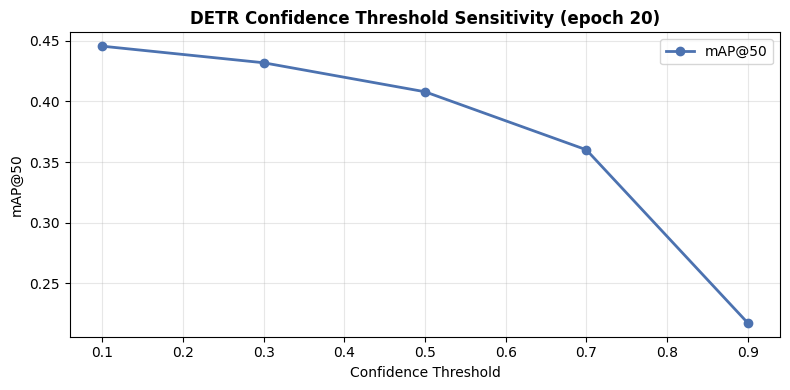

✓ Saved threshold ablation plot


In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, [threshold_results[t]["map50"] for t in thresholds],
        marker="o", linewidth=2, color="#4C72B0", label="mAP@50")
ax.set_xlabel("Confidence Threshold")
ax.set_ylabel("mAP@50")
ax.set_title("DETR Confidence Threshold Sensitivity (epoch 20)", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(BASE_DIR / "plots" / "detr_threshold_ablation.png", dpi=150)
plt.show()
print(f"✓ Saved threshold ablation plot")

Evaluating epoch 5...


Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

  Epoch 5 → mAP@50: 0.2353
Evaluating epoch 10...


Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

  Epoch 10 → mAP@50: 0.3881
Evaluating epoch 15...


Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

  Epoch 15 → mAP@50: 0.4403
Evaluating epoch 20...


Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

  Epoch 20 → mAP@50: 0.4318


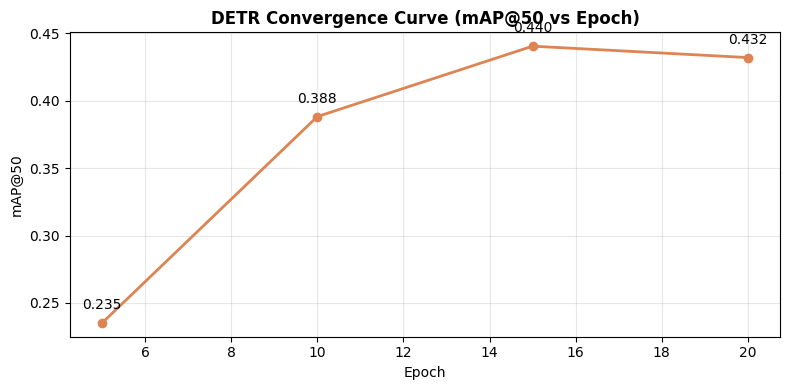

✓ Saved epoch convergence plot


In [8]:
import matplotlib.pyplot as plt

epochs_to_eval = [5, 10, 15, 20]
epoch_results = {}

for ep in epochs_to_eval:
    print(f"Evaluating epoch {ep}...")
    model_ep = DetrForObjectDetection.from_pretrained(
        SAVED_DIR / "detr_rdd2022_full" / f"epoch_{ep}"
    )
    model_ep.to(device)
    model_ep.eval()

    metric_ep = MeanAveragePrecision(iou_type="bbox", iou_thresholds=[0.5])

    with torch.no_grad():
        for i, batch in enumerate(val_dataloader):
            pixel_values = batch["pixel_values"].to(device)
            pixel_mask = batch["pixel_mask"].to(device)
            labels = batch["labels"]

            outputs = model_ep(pixel_values=pixel_values, pixel_mask=pixel_mask)
            target_sizes = torch.stack([t["orig_size"] for t in labels])
            results = processor.post_process_object_detection(
                outputs, threshold=0.3, target_sizes=target_sizes
            )

            preds = [{"boxes": r["boxes"].cpu(), "scores": r["scores"].cpu(), "labels": r["labels"].cpu()} for r in results]
            targets = [{"boxes": yolo_to_xyxy_abs(t["boxes"], t["orig_size"]).cpu(), "labels": t["class_labels"].cpu()} for t in labels]
            metric_ep.update(preds, targets)

    res = metric_ep.compute()
    epoch_results[ep] = res["map_50"].item()
    print(f"  Epoch {ep} → mAP@50: {res['map_50']:.4f}")
    
    del model_ep
    torch.cuda.empty_cache()

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epochs_to_eval, [epoch_results[e] for e in epochs_to_eval],
        marker="o", linewidth=2, color="#DD8452")
ax.set_xlabel("Epoch")
ax.set_ylabel("mAP@50")
ax.set_title("DETR Convergence Curve (mAP@50 vs Epoch)", fontweight="bold")
ax.grid(alpha=0.3)
for ep, val in epoch_results.items():
    ax.annotate(f"{val:.3f}", (ep, val), textcoords="offset points", xytext=(0, 10), ha="center")
plt.tight_layout()
plt.savefig(BASE_DIR / "plots" / "detr_epoch_convergence.png", dpi=150)
plt.show()
print("✓ Saved epoch convergence plot")